### Data Collection & Data Understanding

### Assess the geothermal potential of the area using the provided well data and determine whether the geothermal resources can support the district heating and cooling?


1. Depth  : Shows drilling length                 
2. TVD(True Vertical Depth) : is the actual vertical penetration into Earth 
3 Inclination: is the Well angle from vertical which Indicates deviation               
4. Azimuth : is the direction of drilling which Indicates reservoir targeting     
5 X Offset : is the East-West movement              
6 Y Offset : is  North-South movement                 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Load Excel file
os.chdir("c://working_files") #file path in your PC
xls = pd.ExcelFile("Well_Path_Data.xlsx")

# Read all sheets and combine
all_data = []

for sheet in xls.sheet_names:
    df = pd.read_excel("Well_Path_Data.xlsx", sheet_name=sheet)
    df["Well"] = sheet
    all_data.append(df)

# Combine into one dataframe
geo_df = pd.concat(all_data, ignore_index=True)

# Display first rows
print(geo_df.head())

   Depth (m)  Inclination (º)  Azimuth (º)  TVD (m)  X-offset (m)  \
0       0.00             0.00          0.0     0.00          0.00   
1       6.23             0.00          0.0     6.23          0.00   
2      53.00             0.26          0.0    53.00          0.00   
3     116.00             0.25          0.0   116.00         -0.01   
4     175.10             0.61          0.0   175.10         -0.03   

   Y-offset (m)    Well  
0          0.00  BLT-01  
1          0.00  BLT-01  
2          0.11  BLT-01  
3          0.39  BLT-01  
4          0.83  BLT-01  


In [3]:
geo_df.head()

,Depth (m),Inclination (º),Azimuth (º),TVD (m),X-offset (m),Y-offset (m),Well
0,0.00,0.00,0.0,0.00,0.00,0.00,BLT-01
1,6.23,0.00,0.0,6.23,0.00,0.00,BLT-01
2,53.00,0.26,0.0,53.00,0.00,0.11,BLT-01
3,116.00,0.25,0.0,116.00,-0.01,0.39,BLT-01
4,175.10,0.61,0.0,175.10,-0.03,0.83,BLT-01


In [4]:
geo_df.columns = geo_df.columns.str.strip().str.replace(" ", "_")

In [5]:
geo_df.columns

Index(['Depth_(m)', 'Inclination_(º)', 'Azimuth_(º)', 'TVD_(m)',
       'X-offset_(m)', 'Y-offset_(m)', 'Well'],
      dtype='object')

In [6]:
geo_df.shape

(266, 7)

We have 266 instances and 7 attributes

In [7]:
geo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Depth_(m)        266 non-null    float64
 1   Inclination_(º)  266 non-null    float64
 2   Azimuth_(º)      266 non-null    float64
 3   TVD_(m)          266 non-null    float64
 4   X-offset_(m)     266 non-null    float64
 5   Y-offset_(m)     266 non-null    float64
 6   Well             266 non-null    object 
dtypes: float64(6), object(1)
memory usage: 14.7+ KB


In [8]:
geo_df["Well"].value_counts()

Well
PKP-01    110
BLT-01    102
JUT-01     33
EVD-01     21
Name: count, dtype: int64

### Data Cleaning & Preprocessing 

In [9]:
#check for missing value
geo_df.isnull().sum()

Depth_(m)          0
Inclination_(º)    0
Azimuth_(º)        0
TVD_(m)            0
X-offset_(m)       0
Y-offset_(m)       0
Well               0
dtype: int64

In [10]:
# check for duplicates
geo_df.duplicated().sum()

0

#### Statistical Summary

In [11]:
geo_df.describe()

,Depth_(m),Inclination_(º),Azimuth_(º),TVD_(m),X-offset_(m),Y-offset_(m)
count,266.00000,266.000000,266.000000,266.000000,266.000000,266.000000
mean,1346.44485,18.782293,71.419361,1268.658759,271.655038,191.508797
std,782.41771,11.005575,63.939027,724.283658,288.545097,186.690075
min,0.00000,0.000000,0.000000,0.000000,-8.580000,-4.140000
25%,700.00000,12.487500,53.490000,696.965000,32.337500,30.420000
50%,1300.00000,17.465000,62.200000,1224.115000,177.720000,137.005000
75%,1908.02500,29.967500,64.762500,1794.570000,391.092500,299.140000
max,3409.00000,37.280000,360.000000,3324.610000,1061.190000,638.050000


### EDA
We will explore the data to gain insights

In [35]:
geo_df.select_dtypes(include=['number']).corr()

,Depth_(m),Inclination_(º),Azimuth_(º),TVD_(m),X-offset_(m),Y-offset_(m)
Depth_(m),1.000000,0.396521,-0.133305,0.994480,0.632924,0.825923
Inclination_(º),0.396521,1.000000,-0.274038,0.336850,0.669031,0.662028
Azimuth_(º),-0.133305,-0.274038,1.000000,-0.129463,-0.143316,-0.149307
TVD_(m),0.994480,0.336850,-0.129463,1.000000,0.552016,0.765459
X-offset_(m),0.632924,0.669031,-0.143316,0.552016,1.000000,0.906556
Y-offset_(m),0.825923,0.662028,-0.149307,0.765459,0.906556,1.000000


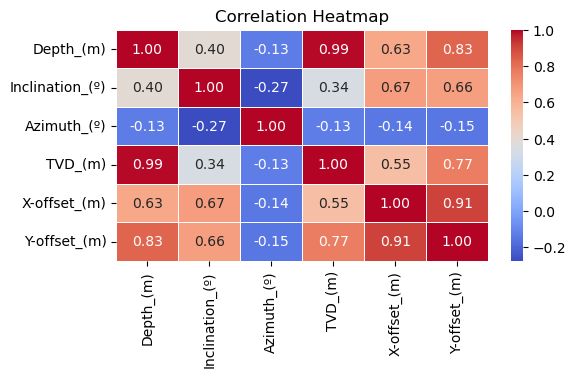

In [12]:
# Create correlation matrix
corr_matrix =geo_df.select_dtypes(include=['number']).corr()
# Plot heatmap
plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm', fmt='.2f',linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

### Well Trajectory Analysis


In [13]:
geo_df.groupby("Well")['Depth_(m)'].max()

Well
BLT-01    2123.0
EVD-01    2197.5
JUT-01    3409.0
PKP-01    2751.0
Name: Depth_(m), dtype: float64

In [14]:
geo_df.groupby("Well")["TVD_(m)"].max()

Well
BLT-01    2051.40
EVD-01    2181.07
JUT-01    3324.61
PKP-01    2404.41
Name: TVD_(m), dtype: float64

In [41]:
# estimating how far the well extends sideways into the geothermal reservoir.
geo_df["Horizontal_Reach"] = np.sqrt(
    geo_df["X-offset_(m)"]**2 +
    geo_df["Y-offset_(m)"]**2
)

In [42]:
geo_df.groupby("Well")["Horizontal_Reach"].max()

Well
BLT-01     499.512057
EVD-01     161.115196
JUT-01     545.142547
PKP-01    1238.237465
Name: Horizontal_Reach, dtype: float64

In [16]:
geo_df.columns

Index(['Depth_(m)', 'Inclination_(º)', 'Azimuth_(º)', 'TVD_(m)',
       'X-offset_(m)', 'Y-offset_(m)', 'Well'],
      dtype='object')

## Visualization

### Max TVD per Well Plot

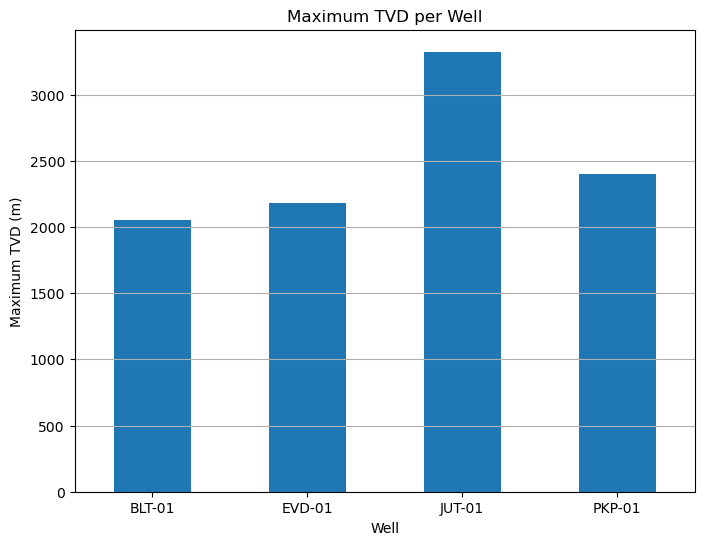

In [45]:
import matplotlib.pyplot as plt

# Get maximum TVD for each well
max_tvd = geo_df.groupby("Well")["TVD_(m)"].max()

# Create bar chart
plt.figure(figsize=(8,6))

max_tvd.plot(kind="bar")

# Labels and title
plt.xlabel("Well")
plt.ylabel("Maximum TVD (m)")
plt.title("Maximum TVD per Well")

# Rotate labels
plt.xticks(rotation=0)

# Add grid
plt.grid(axis='y')

plt.show()

### True Vertical Depth VS Depth plot
The extremely strong positive correlation (0.994) between measured depth and true vertical depth indicates efficient vertical penetration into deeper subsurface formations, which is favorable for geothermal heat extraction.

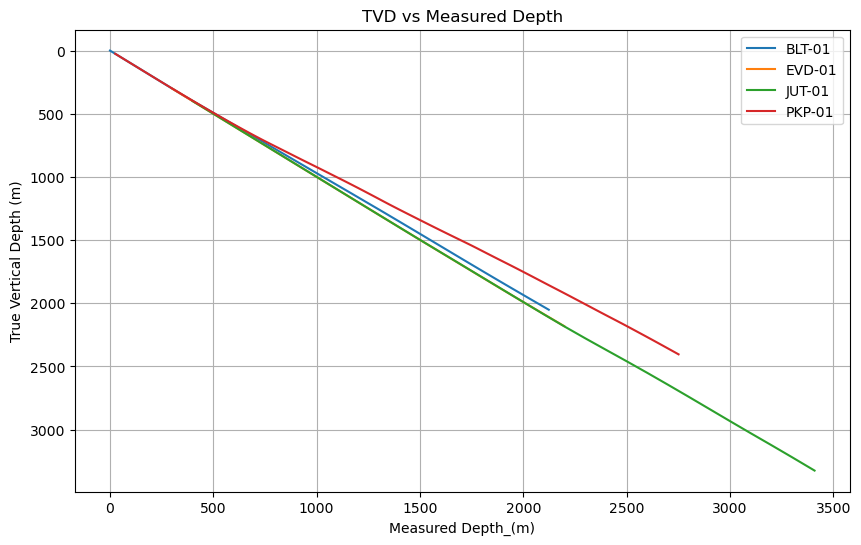

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for well in geo_df["Well"].unique():

    subset = geo_df[geo_df["Well"] == well]

    plt.plot(
        subset['Depth_(m)'],
        subset['TVD_(m)'],
        label=well
    )

plt.xlabel("Measured Depth_(m)")
plt.ylabel("True Vertical Depth (m)")
plt.title("TVD vs Measured Depth")
plt.legend()
plt.gca().invert_yaxis()
plt.grid()
plt.show()

#### Observation : 
1. The wells are not perfectly vertical,they gradually bent sideways underground. It basicallymeans that all well became more deviated with depth
2. JUT-01 penetrates the deepest geothermal formations,it likely reaches hotter subsurface zones,and may have stronger geothermal potential.

#### Well Trajectory

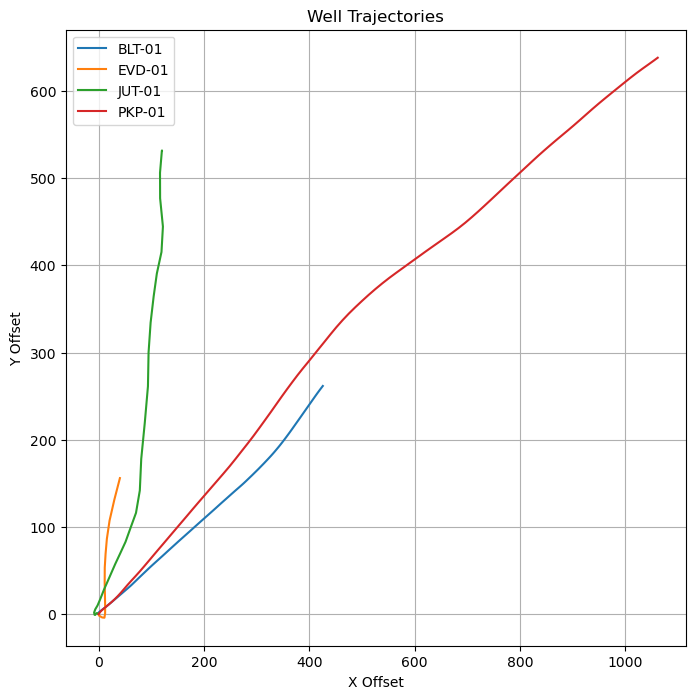

In [29]:
plt.figure(figsize=(8,8))

for well in geo_df["Well"].unique():
    subset = geo_df[geo_df["Well"] == well]

    plt.plot(
        subset["X-offset_(m)"],
        subset["Y-offset_(m)"],
        label=well
    )

plt.xlabel("X Offset")
plt.ylabel("Y Offset")
plt.title("Well Trajectories")
plt.legend()
plt.grid()
plt.show()

#### Observation : 
This shows the drilling directions of the wells. JUT-01 and PKP-01 have stronger geothermal potential

### Inclination Vs Depth

In [32]:
geo_df.columns

Index(['Depth_(m)', 'Inclination_(º)', 'Azimuth_(º)', 'TVD_(m)',
       'X-offset_(m)', 'Y-offset_(m)', 'Well'],
      dtype='object')

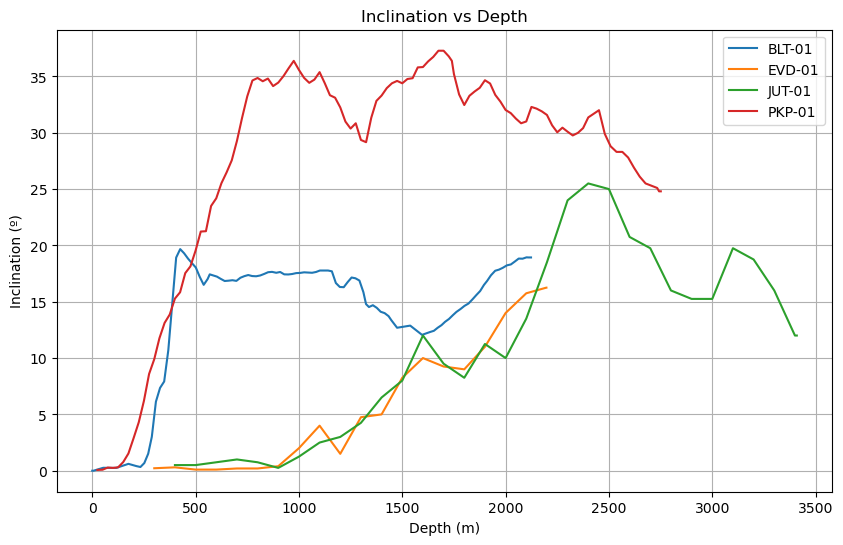

In [36]:
plt.figure(figsize=(10,6))

for well in geo_df["Well"].unique():

    subset = geo_df[geo_df["Well"] == well]

    subset = subset.sort_values("Depth_(m)")

    plt.plot(
        subset["Depth_(m)"],
        subset["Inclination_(º)"],
        label=well
    )

plt.xlabel("Depth (m)")
plt.ylabel("Inclination (º)")
plt.title("Inclination vs Depth")
plt.legend()
plt.grid()
plt.show()

#### Well Comparison

In [44]:
well_summary = geo_df.groupby("Well").agg({"Depth_(m)": "max","TVD_(m)": "max" ,"Horizontal_Reach": "max" })
print(well_summary)

        Depth_(m)  TVD_(m)  Horizontal_Reach
Well                                        
BLT-01     2123.0  2051.40        499.512057
EVD-01     2197.5  2181.07        161.115196
JUT-01     3409.0  3324.61        545.142547
PKP-01     2751.0  2404.41       1238.237465


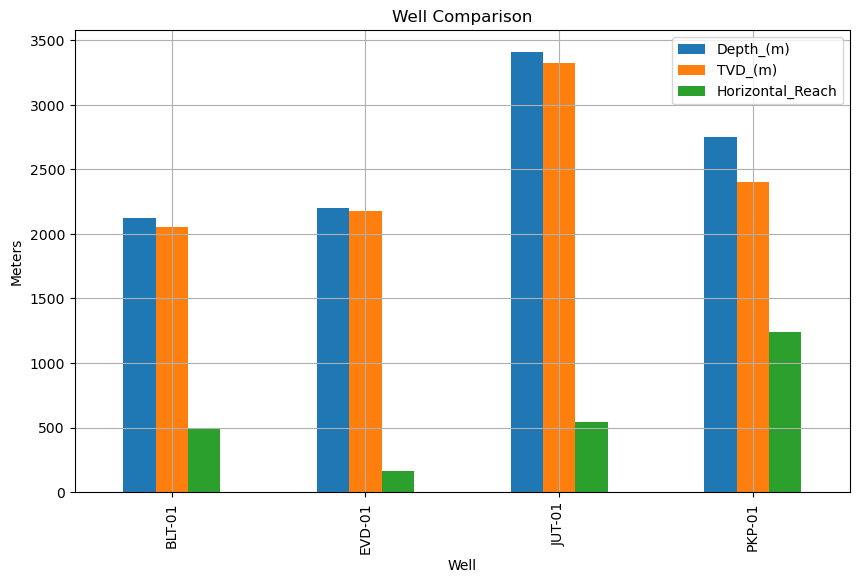

In [46]:
well_summary = geo_df.groupby("Well").agg({"Depth_(m)": "max", "TVD_(m)": "max" ,"Horizontal_Reach": "max"})
#the plot
well_summary.plot(kind="bar",figsize=(10,6))

plt.title("Well Comparison")
plt.ylabel("Meters")
plt.grid()
plt.show()

## Conclusion
The geothermal resources in this area, as characterised by the four-well dataset, demonstrate **sufficient depth, reservoir penetration, and directional coverage** to technically support a district heating and cooling system. JUT-01 and PKP-01 are the primary candidates for production, given their depth and horizontal reach respectively. BLT-01 provides reliable supplementary output, while EVD-01 is best positioned as a monitoring or injection well. Subject to reservoir temperature and flow rate confirmation from the THERMO_GIS production data, the field is assessed as **technically viable for district geothermal heating and cooling development**